# 3.6.2 Tabular Method

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/14Ahxw0xfS34pJgG8OSP_DHsT0LrbFLsk?usp=sharing)

Dynamic programming problems can usually be represented more succinctly in tabular form rather than as a graph. Consider the following problem. A Director of Computing Facilities must decide how to allocate five computer systems among three locations: the Library, the University Computer Center, and the Computer Science Lab. The number of users who can be accommodated through various allocations is shown in Table 3.14.

&nbsp;&nbsp;&nbsp;&nbsp;By viewing this problem as a staged decision process, we can determine the optimal allocation that will provide computer access to the greatest number of users.

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**TABLE 3.14**

<div align="center">

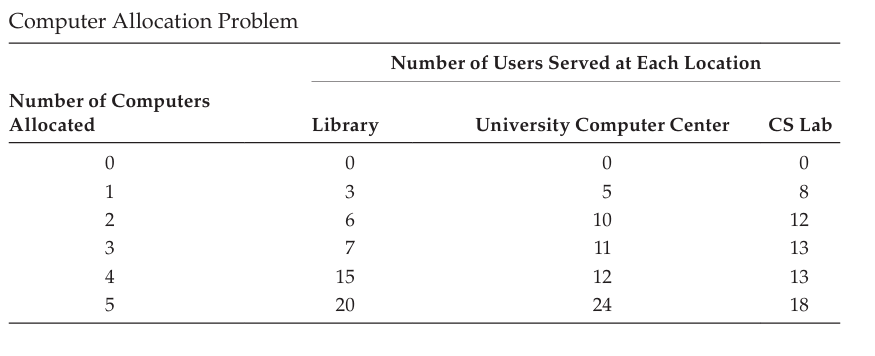

</div>

denote the decision of how many computers to place in the Library, Stage 2 denote the decision for the Computer Center, and Stage 3 for the Computer Science Lab. As before, we will begin with the last stage, and work backward.

&nbsp;&nbsp;&nbsp;&nbsp;At the third stage, we do not know how allocations may be made at earlier stages, but regardless of what earlier allocations may have been decided, we wish to determine the optimal allocation for the remaining available computers. Since this is the last stage, we clearly should allocate all remaining computers, i.e., the ones that were not allocated in Stage 1 and Stage 2, to the Lab, as shown in **Table 3.15**.

&nbsp;&nbsp;&nbsp;&nbsp;At the second stage, the alternatives are somewhat more interesting. Again, we do not know what allocations may be made at earlier stages, Stage 1; but since this is not the last stage, we must consider the possibility of allocating only a portion of what is available, leaving some computers for allocation in Stage 3. The various possible allocations in Stage 2 are shown in **Table 3.16**. Each entry represented by a sum includes the number of users that can be served by placing some computers here at this stage, plus the optimal number that could be served by saving the remaining available computers for later stages.

&nbsp;&nbsp;&nbsp;&nbsp;We can conclude the solution to this problem now by solving Stage 1. In this case, we do not have to consider different numbers of available computers: we know that all five are available because there are no preceding stages during which any could be allocated. We do, however, have the option to allocate any number of them, as shown in **Table 3.17**.

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**TABLE 3.15**

<div align="center">

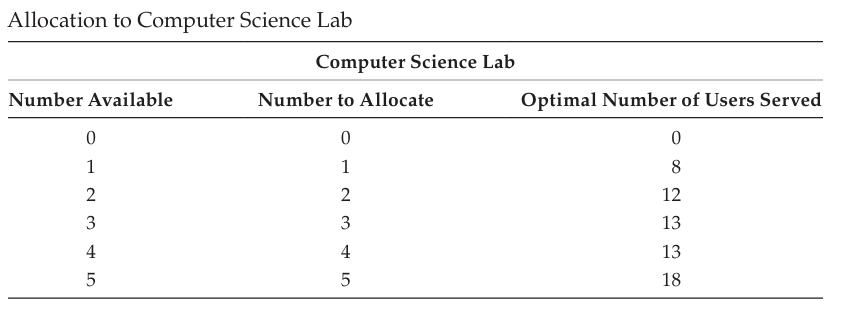

</div>

<br>

&nbsp;&nbsp;**TABLE 3.16**

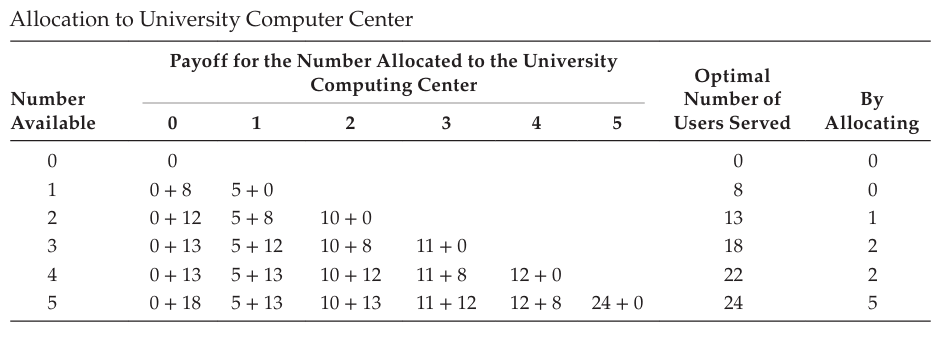

<br>

&nbsp;&nbsp;**TABLE 3.17**

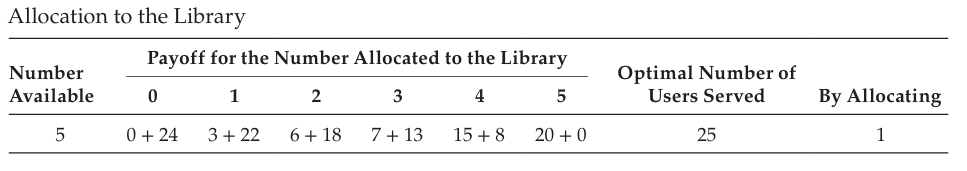

<br>

&nbsp;&nbsp;&nbsp;&nbsp;The problem is now solved. The optimal number of users, 25, that can be served is obtained by allocating one computer to the Library. That leaves 4 available for Stage 2, and from the table for Stage 2, we know that the optimal decision is to allocate 2 to the Computer Center, leaving 2 for Stage 3, the Computer Science Lab. At Stage 3, we allocate both available computers. Thus, by placing 1, 2, and 2 computers, respectively, in the Library, Computer Center, and Lab, we can serve $3 + 10 + 12 = 25$ computer users.

&nbsp;&nbsp;&nbsp;&nbsp;Notice that we could have used a graphical representation of this problem as shown in **Figure 3.20**, and the backward labeling technique, to find the optimal allocation. However, even in a problem of this size, the number of arcs becomes large and

<br>

<div align="center">

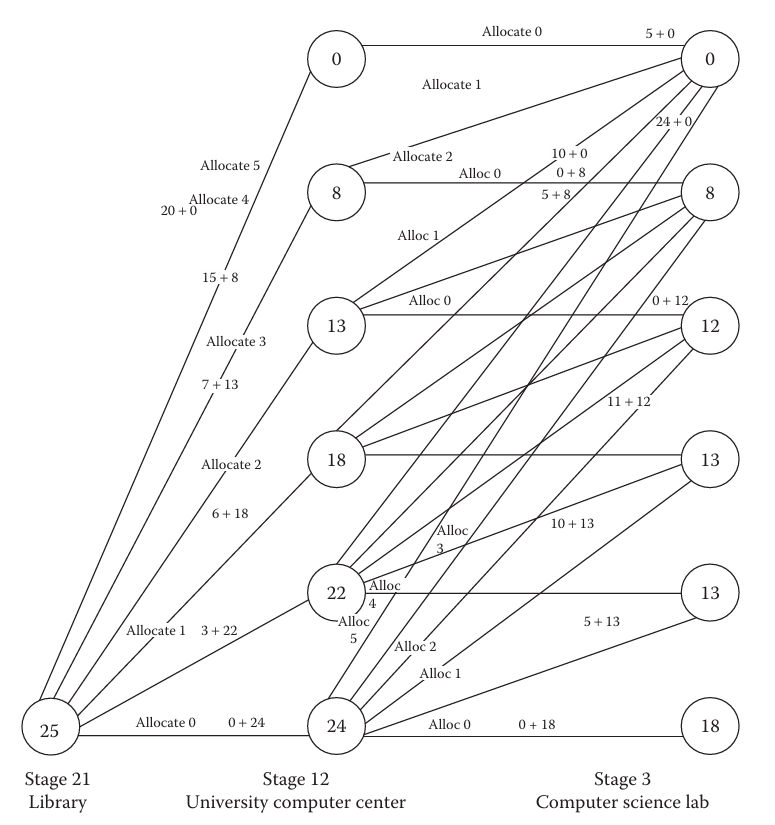

</div>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**FIGURE 3.20** <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Graphical representation of computer allocation problem.

<br>

awkward to display. We accomplish exactly the same thing conceptually using the
more convenient tabular representation.

**Code Implementation**

In [1]:
# ========================================
# 3.6.2 Tabular Method
# Computer Allocation Problem
# ========================================

import pandas as pd

# Table 3.14: users served by each location
users = {
    "Library": [0, 3, 6, 7, 15, 20],
    "Computer Center": [0, 5, 10, 11, 12, 24],
    "CS Lab": [0, 8, 12, 13, 13, 18]
}

N = 5

# Stage 3: CS Lab
# Since this is the last stage, allocate all remaining computers to the CS Lab.
stage3 = []

for available in range(N + 1):
    allocate = available
    value = users["CS Lab"][allocate]

    stage3.append({
        "Number Available": available,
        "Number to Allocate": allocate,
        "Optimal Users Served": value
    })

stage3_df = pd.DataFrame(stage3)

print("Stage 3: CS Lab")
display(stage3_df)

# Stage 2: Computer Center
# Try every possible allocation to the Computer Center.
# Remaining computers go to Stage 3.
stage2 = []
f2 = {}
d2 = {}

for available in range(N + 1):
    best_value = -1
    best_allocate = 0

    for allocate in range(available + 1):
        remaining = available - allocate
        value = users["Computer Center"][allocate] + users["CS Lab"][remaining]

        if value > best_value:
            best_value = value
            best_allocate = allocate

    f2[available] = best_value
    d2[available] = best_allocate

    stage2.append({
        "Number Available": available,
        "Best Number to Allocate": best_allocate,
        "Optimal Users Served": best_value
    })

stage2_df = pd.DataFrame(stage2)

print("Stage 2: Computer Center")
display(stage2_df)

# Stage 1: Library
# All 5 computers are available at the first stage.
stage1 = []
best_total = -1
best_library = 0

for allocate in range(N + 1):
    remaining = N - allocate
    value = users["Library"][allocate] + f2[remaining]

    stage1.append({
        "Number Allocated to Library": allocate,
        "Users Served by Library": users["Library"][allocate],
        "Best Users from Later Stages": f2[remaining],
        "Total Users Served": value
    })

    if value > best_total:
        best_total = value
        best_library = allocate

stage1_df = pd.DataFrame(stage1)

print("Stage 1: Library")
display(stage1_df)

# Reconstruct the optimal allocation
library_allocation = best_library
computer_center_allocation = d2[N - library_allocation]
cs_lab_allocation = N - library_allocation - computer_center_allocation

print("Optimal Allocation:")
print("Library:", library_allocation, "computer(s)")
print("Computer Center:", computer_center_allocation, "computer(s)")
print("CS Lab:", cs_lab_allocation, "computer(s)")
print("Maximum users served:", best_total)

Stage 3: CS Lab


,Number Available,Number to Allocate,Optimal Users Served
0,0,0,0
1,1,1,8
2,2,2,12
3,3,3,13
4,4,4,13
5,5,5,18


Stage 2: Computer Center


,Number Available,Best Number to Allocate,Optimal Users Served
0,0,0,0
1,1,0,8
2,2,1,13
3,3,2,18
4,4,2,22
5,5,5,24


Stage 1: Library


,Number Allocated to Library,Users Served by Library,Best Users from Later Stages,Total Users Served
0,0,0,24,24
1,1,3,22,25
2,2,6,18,24
3,3,7,13,20
4,4,15,8,23
5,5,20,0,20


Optimal Allocation:
Library: 1 computer(s)
Computer Center: 2 computer(s)
CS Lab: 2 computer(s)
Maximum users served: 25
